# MNIST Classification — CNN (PyTorch)

## Goal
Use a Convolutional Neural Network to classify handwritten digits while preserving spatial structure.

## Key Idea
- No flattening at input
- Use Conv2D to extract features

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

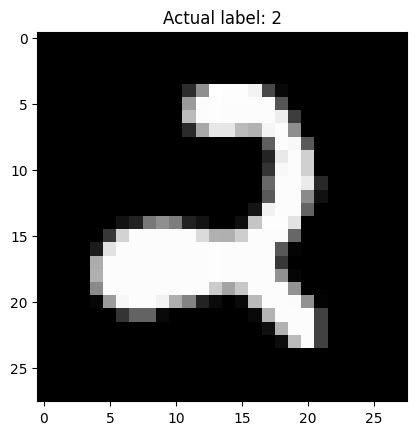

In [5]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    "./data",
    train = True,
    transform= transform,
    download= True
)

test_dataset =datasets.MNIST(
    './data',
    train = False,
    transform = transform,
    download = True
)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32)
images, labels = next(iter(train_loader))

import matplotlib.pyplot as plt
plt.imshow(images[0].squeeze(), cmap = 'grey')
plt.title(f"Actual label: {labels[0]}")
plt.show()


In [6]:
model = nn.Sequential(
    nn.Conv2d(in_channels = 1, out_channels= 8, kernel_size = 3),
    nn.ReLU(),
    nn.Flatten(),
    nn.Linear(8*26*26, 10)
)

print(model)


Sequential(
  (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): Flatten(start_dim=1, end_dim=-1)
  (3): Linear(in_features=5408, out_features=10, bias=True)
)


In [8]:
outputs = model(images)
print("output shape: ", outputs.shape)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)

output shape:  torch.Size([32, 10])


In [9]:
######### training ################
for epoch in range(3):
  for images, labels in train_loader:
    outputs = model(images)
    loss = loss_fn(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  print("Epoch: ", epoch, "done")

Epoch:  0 done
Epoch:  1 done
Epoch:  2 done


In [10]:
####### inference ################
correct = 0
total = 0

with torch.no_grad():
  for images, labels in test_loader:
    outputs= model(images)
    _, preds = torch.max(outputs, dim = 1)
    correct += (preds == labels).sum().item()
    total += len(labels)

  accuracy = correct/total*100
  print("Accuracy = ", accuracy, "%")

Accuracy =  96.84 %


### Result
Test Accuracy= 96.84%

## Key Insights

- CNNs preserve spatial relationships using convolutional filters, unlike fully connected networks which flatten inputs.

- Each convolutional layer produces multiple feature maps (equal to number of filters), capturing different patterns.

- Output feature map size (for stride = 1, no padding):
  
  output_size = input_size - kernel_size + 1

- Flatten layer converts feature maps into a 1D vector for the Linear layer.